In [ ]:
!pip install qiskit qiskit-aer
!pip install pylatexenc


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=4affb1933e667fe6f88db6bf902a410c32042a0dbcc3e1936326705403ef2cb0
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
import warnings
warnings.filterwarnings('ignore')

# ============================================
# EJERCICIO 1: Molécula NH₃ - Oscilaciones Rabi
# ============================================

def rabi_oscillation_nh3():
    """
    Calcula y visualiza las oscilaciones de Rabi para la molécula NH₃

    Fundamentos teóricos:
    - La molécula NH₃ tiene dos estados simétricos |1⟩ y |2⟩
    - El splitting de energía ΔE corresponde a frecuencia ω₀ = 24.79 GHz
    - La inversión del nitrógeno ocurre por efecto túnel cuántico
    """

    print("="*60)
    print("EJERCICIO 1: Molécula NH₃ - Oscilaciones de Rabi")
    print("="*60)

    # Parámetros físicos de la molécula NH₃
    f0 = 24.79e9  # Frecuencia de transición en Hz (24.79 GHz)
    omega_0 = 2 * np.pi * f0  # Frecuencia angular de transición

    print(f"\nParámetros de la molécula NH₃:")
    print(f"  Frecuencia de transición: f₀ = {f0/1e9:.2f} GHz")
    print(f"  Frecuencia angular: ω₀ = {omega_0:.3e} rad/s")
    print(f"  Energía de splitting: ΔE = ℏω₀ = {1.0545718e-34 * omega_0:.3e} J")

    # Parámetros de la simulación
    # Consideramos diferentes frecuencias de detuning
    detunings = [0, 0.1e9, 0.5e9, 1.0e9]  # Detuning en Hz

    # Frecuencia de Rabi para diferentes amplitudes de campo
    # Ω_R = sqrt(Ω₀² + δ²) donde Ω₀ es la frecuencia de Rabi en resonancia
    # y δ = ω - ω₀ es el detuning

    # Caso resonante (δ = 0)
    # Suponemos un acoplamiento Ω₀ típico para NH₃
    Omega_0 = 1.0e6  # Frecuencia de Rabi en resonancia (1 MHz típico)

    # Tiempo de simulación
    t_max = 10 / Omega_0  # 10 periodos de Rabi en resonancia
    t = np.linspace(0, t_max, 1000)

    # Crear figura para las oscilaciones de Rabi
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Oscilaciones de Rabi en la Molécula NH₃', fontsize=16, fontweight='bold')

    colors = ['blue', 'red', 'green', 'purple']

    for idx, delta in enumerate(detunings):
        ax = axes[idx // 2, idx % 2]
        delta_omega = 2 * np.pi * delta

        # Frecuencia de Rabi generalizada
        Omega_R = np.sqrt(Omega_0**2 + delta_omega**2)

        # Probabilidades de los estados |1⟩ y |2⟩
        # Partiendo del estado inicial |1⟩ = (1, 0)ᵀ
        # P₁(t) = 1 - (Ω₀²/Ω_R²) sin²(Ω_R t/2)
        # P₂(t) = (Ω₀²/Ω_R²) sin²(Ω_R t/2)

        amplitude_factor = (Omega_0**2) / (Omega_R**2)

        P1 = 1 - amplitude_factor * np.sin(Omega_R * t / 2)**2
        P2 = amplitude_factor * np.sin(Omega_R * t / 2)**2

        # Graficar probabilidades
        ax.plot(t * 1e6, P1, 'b-', linewidth=2, label='|1⟩ (N arriba)')
        ax.plot(t * 1e6, P2, 'r--', linewidth=2, label='|2⟩ (N abajo)')

        ax.set_xlabel('Tiempo (μs)', fontsize=11)
        ax.set_ylabel('Probabilidad', fontsize=11)
        ax.set_title(f'Detuning δ = {delta/1e6:.1f} MHz\nΩ_R = {Omega_R/1e6:.3f} MHz',
                    fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([-0.05, 1.05])

        # Añadir información sobre la frecuencia de Rabi
        ax.text(0.02, 0.98, f'Ω_R = {Omega_R/1e6:.2f} MHz\nδ = {delta/1e6:.1f} MHz',
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.savefig('nh3_rabi_oscillations.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Análisis detallado del caso resonante
    print(f"\n{'='*50}")
    print("ANÁLISIS DEL CASO RESONANTE (δ = 0)")
    print(f"{'='*50}")
    print(f"Frecuencia de Rabi en resonancia: Ω₀ = {Omega_0/1e6:.2f} MHz")
    print(f"Periodo de Rabi: T_R = {2*np.pi/Omega_0*1e6:.2f} μs")
    print(f"Tiempo para inversión completa: T_R/2 = {np.pi/Omega_0*1e6:.2f} μs")

    # Evolución temporal del estado cuántico
    print(f"\nEvolución temporal del estado cuántico:")
    print(f"|ψ(t)⟩ = cos(Ω_R t/2)|1⟩ - i sin(Ω_R t/2)|2⟩")
    print(f"\nProbabilidades:")
    print(f"P₁(t) = cos²(Ω_R t/2) = (1 + cos(Ω_R t))/2")
    print(f"P₂(t) = sin²(Ω_R t/2) = (1 - cos(Ω_R t))/2")

    # Mostrar valores en tiempos característicos
    t_pi = np.pi / Omega_0  # Tiempo para pulso π
    t_pi2 = np.pi / (2 * Omega_0)  # Tiempo para pulso π/2

    print(f"\nEstados en tiempos característicos:")
    print(f"En t = 0: |ψ⟩ = |1⟩ (100% estado |1⟩)")
    print(f"En t = π/(2Ω₀) = {t_pi2*1e6:.2f} μs: Superposición igual |ψ⟩ = (|1⟩ - i|2⟩)/√2")
    print(f"En t = π/Ω₀ = {t_pi*1e6:.2f} μs: |ψ⟩ = |2⟩ (100% estado |2⟩)")

    return Omega_0, detunings

def analytical_solution_two_level():
    """
    Solución analítica completa del sistema de dos niveles
    """
    print("\n" + "="*60)
    print("SOLUCIÓN ANALÍTICA DEL SISTEMA DE DOS NIVELES")
    print("="*60)

    print("""
Hamiltoniano del sistema:
H = (ℏ/2) * [ -ω₀    Ω₀e^{-iωt} ]
            [ Ω₀e^{iωt}    ω₀    ]

En la representación de interacción y aplicando RWA:
H_I = (ℏ/2) * [ -δ    Ω₀ ]
              [ Ω₀    δ  ]

donde δ = ω - ω₀ es el detuning.

Frecuencia de Rabi generalizada:
Ω_R = √(Ω₀² + δ²)

Evolución temporal (estado inicial |1⟩):
|ψ(t)⟩ = [cos(Ω_R t/2) - i(δ/Ω_R)sin(Ω_R t/2)]|1⟩
         - i(Ω₀/Ω_R)sin(Ω_R t/2)|2⟩

Probabilidad de transición:
P₂(t) = (Ω₀²/Ω_R²) sin²(Ω_R t/2)

Esta es la fórmula de Rabi, que describe oscilaciones entre los dos estados
con frecuencia Ω_R. La amplitud máxima de oscilación es Ω₀²/Ω_R².
    """)

    # Demostración numérica
    print("\nDemostración numérica para NH₃:")

    f0 = 24.79e9  # Hz
    omega_0 = 2 * np.pi * f0

    # Parámetros típicos de experimento
    Omega_0_values = [0.1e6, 0.5e6, 1.0e6, 2.0e6]  # Hz

    for Omega_0 in Omega_0_values:
        T_R = 2 * np.pi / Omega_0
        print(f"\nΩ₀ = {Omega_0/1e3:.1f} kHz:")
        print(f"  Periodo de Rabi: T_R = {T_R*1e6:.2f} μs")
        print(f"  Tiempo pulso π: t_π = {T_R/2*1e6:.2f} μs")
        print(f"  Tiempo pulso π/2: t_{np.pi/2} = {T_R/4*1e6:.2f} μs")

# No llamar a las funciones directamente aquí. El flujo se controla con main().
# rabi_oscillation_nh3()
# analyze_entanglement()
# analytical_solution_two_level()


               LABORATORIO 9: COMPUTACIÓN CUÁNTICA
          Oscilaciones de Rabi y Estados de Bell

🔬 EJERCICIO 1: Molécula NH₃ y Oscilaciones de Rabi
EJERCICIO 1: Molécula NH₃ - Oscilaciones de Rabi

Parámetros de la molécula NH₃:
  Frecuencia de transición: f₀ = 24.79 GHz
  Frecuencia angular: ω₀ = 1.558e+11 rad/s
  Energía de splitting: ΔE = ℏω₀ = 1.643e-23 J


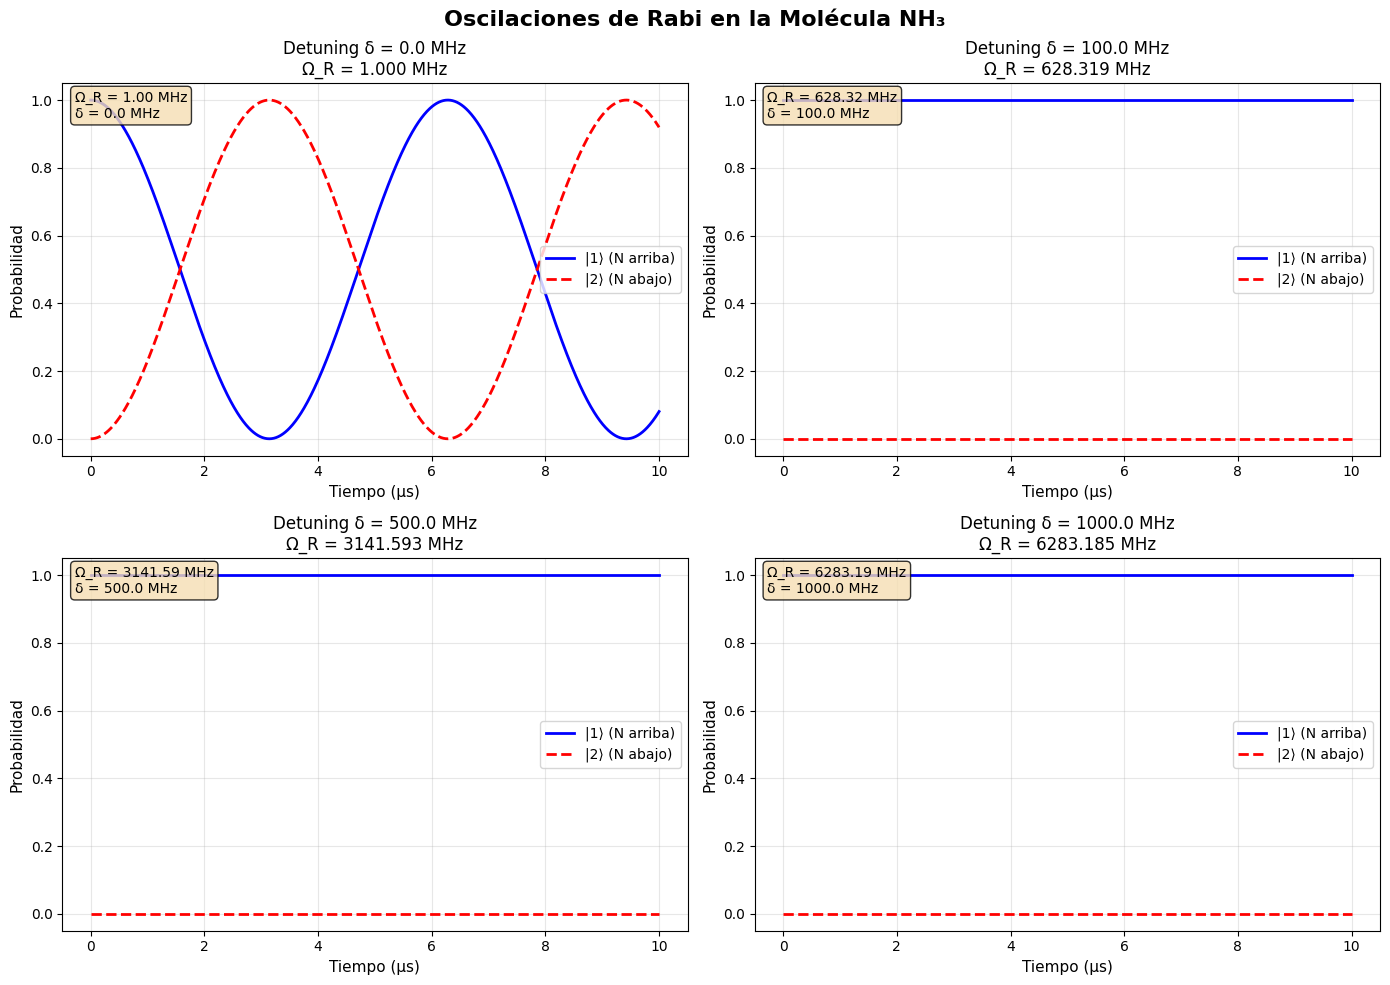


ANÁLISIS DEL CASO RESONANTE (δ = 0)
Frecuencia de Rabi en resonancia: Ω₀ = 1.00 MHz
Periodo de Rabi: T_R = 6.28 μs
Tiempo para inversión completa: T_R/2 = 3.14 μs

Evolución temporal del estado cuántico:
|ψ(t)⟩ = cos(Ω_R t/2)|1⟩ - i sin(Ω_R t/2)|2⟩

Probabilidades:
P₁(t) = cos²(Ω_R t/2) = (1 + cos(Ω_R t))/2
P₂(t) = sin²(Ω_R t/2) = (1 - cos(Ω_R t))/2

Estados en tiempos característicos:
En t = 0: |ψ⟩ = |1⟩ (100% estado |1⟩)
En t = π/(2Ω₀) = 1.57 μs: Superposición igual |ψ⟩ = (|1⟩ - i|2⟩)/√2
En t = π/Ω₀ = 3.14 μs: |ψ⟩ = |2⟩ (100% estado |2⟩)

SOLUCIÓN ANALÍTICA DEL SISTEMA DE DOS NIVELES

Hamiltoniano del sistema:
H = (ℏ/2) * [ -ω₀    Ω₀e^{-iωt} ]
            [ Ω₀e^{iωt}    ω₀    ]

En la representación de interacción y aplicando RWA:
H_I = (ℏ/2) * [ -δ    Ω₀ ]
              [ Ω₀    δ  ]

donde δ = ω - ω₀ es el detuning.

Frecuencia de Rabi generalizada:
Ω_R = √(Ω₀² + δ²)

Evolución temporal (estado inicial |1⟩):
|ψ(t)⟩ = [cos(Ω_R t/2) - i(δ/Ω_R)sin(Ω_R t/2)]|1⟩
         - i(Ω₀/Ω_R)sin(

<Figure size 640x480 with 0 Axes>


----------------------------------------
Parte 2: Estado GHZ de 3 Qubits |GHZ⟩
----------------------------------------

Circuito para estado GHZ de 3 qubits:
     ┌───┐          ┌─┐      
q_0: ┤ H ├──■───────┤M├──────
     └───┘┌─┴─┐     └╥┘┌─┐   
q_1: ─────┤ X ├──■───╫─┤M├───
          └───┘┌─┴─┐ ║ └╥┘┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     0  1  2 

Vector de estado |GHZ⟩:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))

Estado |GHZ⟩ = (|000⟩ + |111⟩)/√2
Amplitudes de probabilidad:
  |000⟩: 0.7071+0.0000j
  |111⟩: 0.7071+0.0000j

Resultados de 1024 mediciones:
{'111': 507, '000': 517}


<Figure size 640x480 with 0 Axes>


----------------------------------------
Parte 3: Estado GHZ con compuerta X en qubit 1
----------------------------------------

Circuito GHZ modificado con X en qubit 1:
     ┌───┐          ┌─┐        
q_0: ┤ H ├──■───────┤M├────────
     └───┘┌─┴─┐     └╥┘┌───┐┌─┐
q_1: ─────┤ X ├──■───╫─┤ X ├┤M├
          └───┘┌─┴─┐ ║ └┬─┬┘└╥┘
q_2: ──────────┤ X ├─╫──┤M├──╫─
               └───┘ ║  └╥┘  ║ 
c: 3/════════════════╩═══╩═══╩═
                     0   2   1 

Vector de estado modificado:
Statevector([0.        +0.j, 0.        +0.j, 0.70710678+0.j,
             0.        +0.j, 0.        +0.j, 0.70710678+0.j,
             0.        +0.j, 0.        +0.j],
            dims=(2, 2, 2))

Estado resultante: (|010⟩ + |101⟩)/√2
Amplitudes de probabilidad:
  |010⟩: 0.7071+0.0000j
  |101⟩: 0.7071+0.0000j

Resultados de 1024 mediciones:
{'010': 526, '101': 498}


<Figure size 640x480 with 0 Axes>

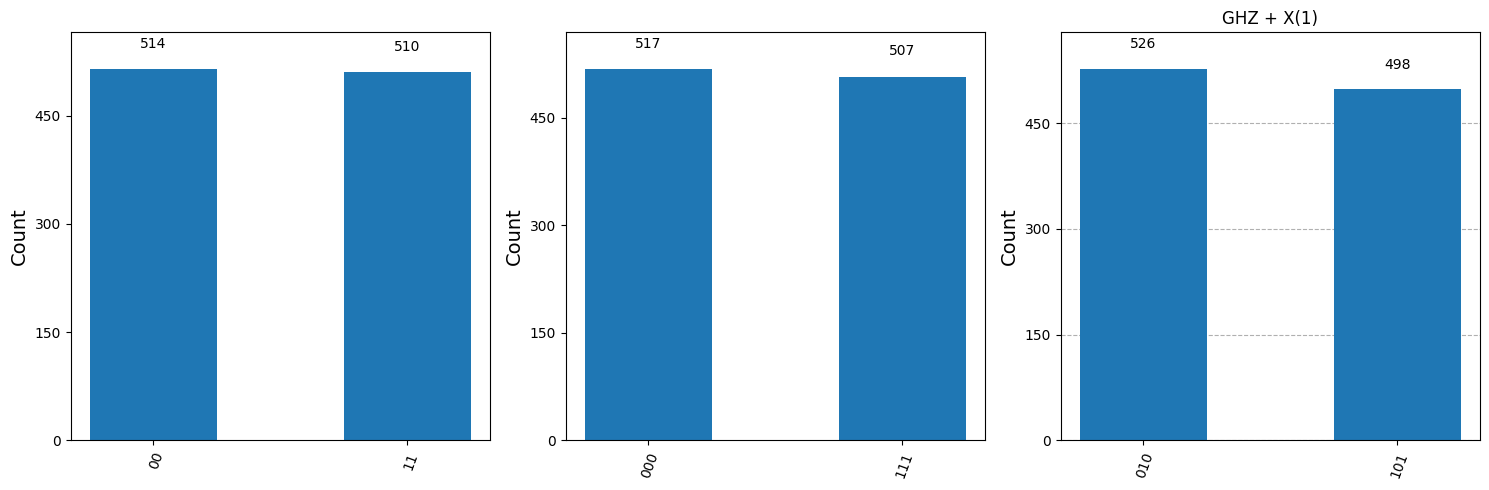


ANÁLISIS DEL ENTRELAZAMIENTO CUÁNTICO

1. ESTADOS DE BELL (2 QUBITS):
   Los cuatro estados de Bell forman una base ortonormal del espacio de 2 qubits:

   |Φ⁺⟩ = (|00⟩ + |11⟩)/√2  →  Máximo entrelazamiento
   |Φ⁻⟩ = (|00⟩ - |11⟩)/√2  →  Máximo entrelazamiento
   |Ψ⁺⟩ = (|01⟩ + |10⟩)/√2  →  Máximo entrelazamiento
   |Ψ⁻⟩ = (|01⟩ - |10⟩)/√2  →  Máximo entrelazamiento

2. CONSTRUCCIÓN DEL ESTADO |Φ⁺⟩:
   Paso 1: Hadamard en qubit 0
            |0⟩ → (|0⟩ + |1⟩)/√2
            Estado: (|00⟩ + |10⟩)/√2

   Paso 2: CNOT(control=0, target=1)
            |00⟩ → |00⟩
            |10⟩ → |11⟩
            Estado final: (|00⟩ + |11⟩)/√2 = |Φ⁺⟩

3. ESTADO GHZ (3 QUBITS):
   Generalización del estado de Bell a 3 qubits:
   |GHZ⟩ = (|000⟩ + |111⟩)/√2

   Construcción:
   Paso 1: H(0) → (|000⟩ + |100⟩)/√2
   Paso 2: CNOT(0,1) → (|000⟩ + |110⟩)/√2
   Paso 3: CNOT(1,2) → (|000⟩ + |111⟩)/√2

4. EFECTO DE LA COMPUERTA X EN QUBIT 1:
   Al aplicar X(1) al estado GHZ:
   |000⟩ → |010⟩
   |111⟩ → |101⟩
   Re

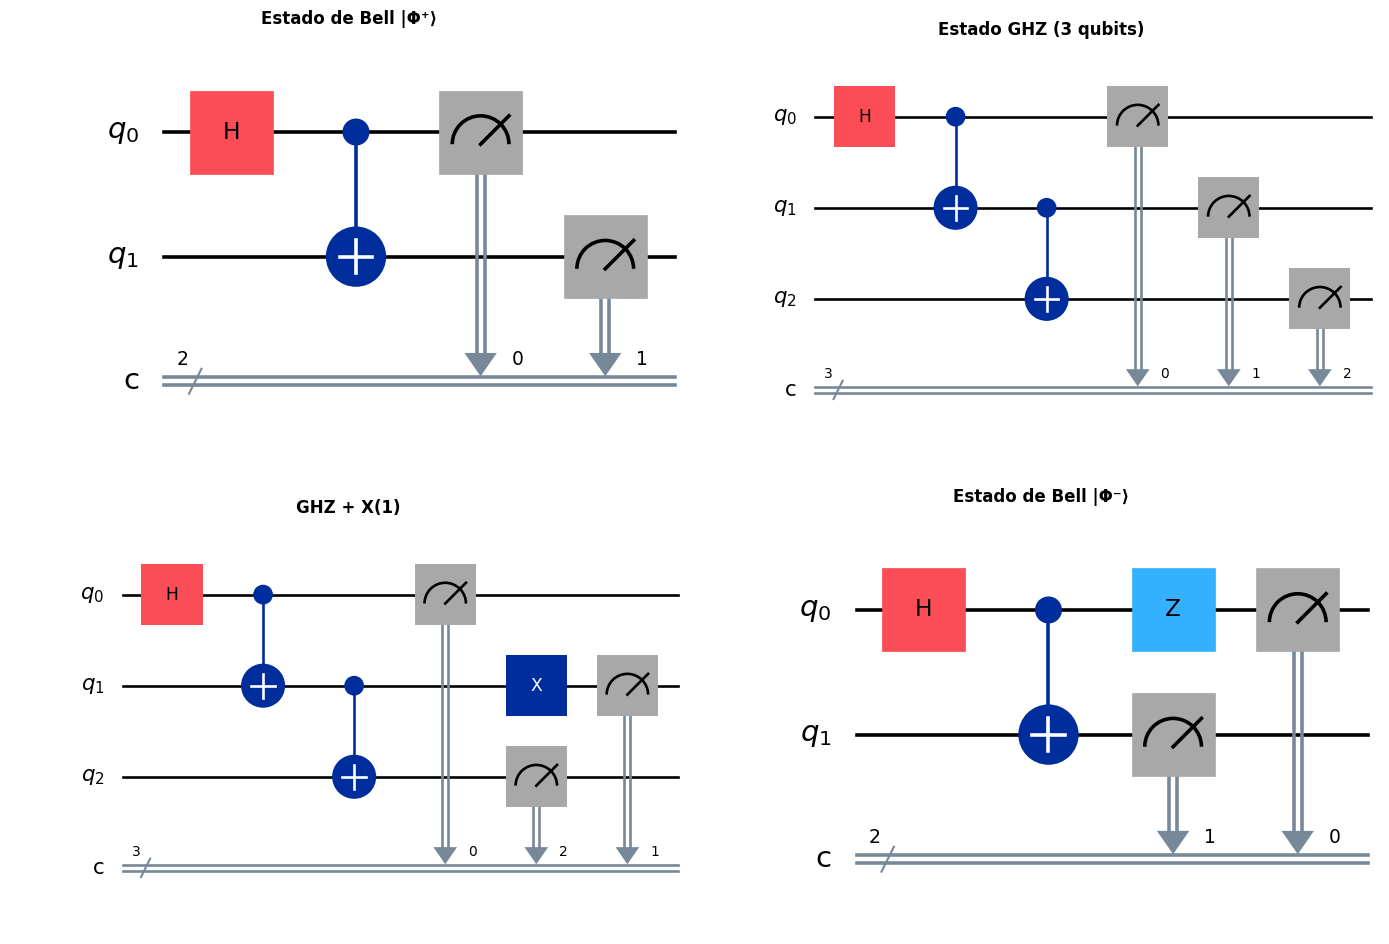


Circuitos cuánticos generados y visualizados exitosamente.

RESUMEN Y CONCLUSIONES

1. OSCILACIONES DE RABI EN NH₃:
   ✓ La molécula de amoníaco exhibe oscilaciones cuánticas entre dos estados
   ✓ La frecuencia de transición es f₀ = 24.79 GHz
   ✓ El fenómeno se describe perfectamente por el modelo de Rabi
   ✓ Las oscilaciones son análogas a un qubit en computación cuántica
   ✓ La frecuencia de Rabi depende del acoplamiento y el detuning

2. ESTADOS DE BELL Y ENTRELAZAMIENTO:
   ✓ Se construyeron exitosamente estados de Bell de 2 y 3 qubits
   ✓ Las mediciones confirman correlaciones cuánticas perfectas
   ✓ El estado GHZ generaliza el entrelazamiento a múltiples qubits
   ✓ Las compuertas cuánticas permiten manipular el entrelazamiento
   ✓ Los resultados coinciden con las predicciones teóricas

3. APLICACIONES PRÁCTICAS:
   • Computación cuántica: Qubits como unidad de información
   • Criptografía cuántica: Distribución cuántica de claves (BB84, E91)
   • Teleportación cuántica:

In [ ]:

# ============================================
# EJERCICIO 2: Estados de Bell
# ============================================

def create_bell_states():
    """
    Crear y analizar estados de Bell usando Qiskit
    """
    print("\n" + "="*60)
    print("EJERCICIO 2: Estados de Bell y Entrelazamiento")
    print("="*60)

    # Usar el simulador Aer
    simulator = Aer.get_backend('statevector_simulator')
    qasm_simulator = Aer.get_backend('qasm_simulator')

    # ========================================
    # Parte 1: Estado de Bell de 2 qubits
    # ========================================
    print("\n" + "-"*40)
    print("Parte 1: Estado de Bell de 2 Qubits |Φ⁺⟩")
    print("-"*40)

    # Crear circuito para estado de Bell |Φ⁺⟩ = (|00⟩ + |11⟩)/√2
    qr = QuantumRegister(2, 'q')
    cr = ClassicalRegister(2, 'c')
    qc_bell = QuantumCircuit(qr, cr)

    # Construir estado de Bell
    qc_bell.h(0)      # Hadamard en qubit 0
    qc_bell.cx(0, 1)  # CNOT con control q0 y target q1

    # Mediciones
    qc_bell.measure(qr, cr)

    print("\nCircuito para estado de Bell |Φ⁺⟩:")
    print(qc_bell.draw())

    # Obtener vector de estado
    qc_no_measure = qc_bell.remove_final_measurements(inplace=False)
    state = Statevector.from_instruction(qc_no_measure)

    print("\nVector de estado |Φ⁺⟩:")
    print(state)
    print("\nEstado |Φ⁺⟩ = (|00⟩ + |11⟩)/√2")
    print("Amplitudes de probabilidad:")
    for i, amp in enumerate(state.data):
        print(f"  |{i:02b}⟩: {amp:.4f}")

    # Simular mediciones
    shots = 1024
    job = qasm_simulator.run(qc_bell, shots=shots)
    counts = job.result().get_counts()

    print(f"\nResultados de {shots} mediciones:")
    print(counts)

    # Visualizar histograma
    fig = plot_histogram(counts, title='Estado de Bell |Φ⁺⟩ - 2 Qubits')
    plt.savefig('bell_state_2qubits.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ========================================
    # Parte 2: Estado GHZ de 3 qubits
    # ========================================
    print("\n" + "-"*40)
    print("Parte 2: Estado GHZ de 3 Qubits |GHZ⟩")
    print("-"*40)

    # Crear circuito para estado GHZ de 3 qubits
    qr3 = QuantumRegister(3, 'q')
    cr3 = ClassicalRegister(3, 'c')
    qc_ghz = QuantumCircuit(qr3, cr3)

    # Construir estado GHZ: (|000⟩ + |111⟩)/√2
    qc_ghz.h(0)       # Hadamard en qubit 0
    qc_ghz.cx(0, 1)   # CNOT control q0, target q1
    qc_ghz.cx(1, 2)   # CNOT control q1, target q2

    # Mediciones
    qc_ghz.measure(qr3, cr3)

    print("\nCircuito para estado GHZ de 3 qubits:")
    print(qc_ghz.draw())

    # Vector de estado
    qc_ghz_no_measure = qc_ghz.remove_final_measurements(inplace=False)
    state_ghz = Statevector.from_instruction(qc_ghz_no_measure)

    print("\nVector de estado |GHZ⟩:")
    print(state_ghz)
    print("\nEstado |GHZ⟩ = (|000⟩ + |111⟩)/√2")
    print("Amplitudes de probabilidad:")
    for i, amp in enumerate(state_ghz.data):
        if abs(amp) > 1e-10:
            print(f"  |{i:03b}⟩: {amp:.4f}")

    # Simular mediciones
    shots = 1024
    job_ghz = qasm_simulator.run(qc_ghz, shots=shots)
    counts_ghz = job_ghz.result().get_counts()

    print(f"\nResultados de {shots} mediciones:")
    print(counts_ghz)

    # Visualizar
    fig = plot_histogram(counts_ghz, title='Estado GHZ - 3 Qubits')
    plt.savefig('ghz_state_3qubits.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ========================================
    # Parte 3: Añadir compuerta X al final
    # ========================================
    print("\n" + "-"*40)
    print("Parte 3: Estado GHZ con compuerta X en qubit 1")
    print("-"*40)

    # Crear circuito modificado
    qr3_mod = QuantumRegister(3, 'q')
    cr3_mod = ClassicalRegister(3, 'c')
    qc_ghz_mod = QuantumCircuit(qr3_mod, cr3_mod)

    # Construir estado GHZ
    qc_ghz_mod.h(0)
    qc_ghz_mod.cx(0, 1)
    qc_ghz_mod.cx(1, 2)

    # Añadir compuerta X en qubit 1
    qc_ghz_mod.x(1)

    # Mediciones
    qc_ghz_mod.measure(qr3_mod, cr3_mod)

    print("\nCircuito GHZ modificado con X en qubit 1:")
    print(qc_ghz_mod.draw())

    # Vector de estado
    qc_ghz_mod_no_measure = qc_ghz_mod.remove_final_measurements(inplace=False)
    state_ghz_mod = Statevector.from_instruction(qc_ghz_mod_no_measure)

    print("\nVector de estado modificado:")
    print(state_ghz_mod)
    print("\nEstado resultante: (|010⟩ + |101⟩)/√2")
    print("Amplitudes de probabilidad:")
    for i, amp in enumerate(state_ghz_mod.data):
        if abs(amp) > 1e-10:
            print(f"  |{i:03b}⟩: {amp:.4f}")

    # Simular mediciones
    shots = 1024
    job_ghz_mod = qasm_simulator.run(qc_ghz_mod, shots=shots)
    counts_ghz_mod = job_ghz_mod.result().get_counts()

    print(f"\nResultados de {shots} mediciones:")
    print(counts_ghz_mod)

    # Visualizar
    fig = plot_histogram(counts_ghz_mod, title='GHZ modificado con X(1)')
    plt.savefig('ghz_modified_x1.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Comparación de todos los estados
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Bell 2 qubits
    plot_histogram(counts, ax=axes[0], title='Bell |Φ⁺⟩ (2 qubits)')

    # GHZ 3 qubits
    plot_histogram(counts_ghz, ax=axes[1], title='GHZ (3 qubits)')

    # GHZ modificado
    plot_histogram(counts_ghz_mod, ax=axes[2], title='GHZ + X(1)')

    plt.tight_layout()
    plt.savefig('all_states_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    return counts, counts_ghz, counts_ghz_mod

def analyze_entanglement():
    """
    Análisis detallado del entrelazamiento
    """
    print("\n" + "="*60)
    print("ANÁLISIS DEL ENTRELAZAMIENTO CUÁNTICO")
    print("="*60)

    print("""
1. ESTADOS DE BELL (2 QUBITS):
   Los cuatro estados de Bell forman una base ortonormal del espacio de 2 qubits:

   |Φ⁺⟩ = (|00⟩ + |11⟩)/√2  →  Máximo entrelazamiento
   |Φ⁻⟩ = (|00⟩ - |11⟩)/√2  →  Máximo entrelazamiento
   |Ψ⁺⟩ = (|01⟩ + |10⟩)/√2  →  Máximo entrelazamiento
   |Ψ⁻⟩ = (|01⟩ - |10⟩)/√2  →  Máximo entrelazamiento

2. CONSTRUCCIÓN DEL ESTADO |Φ⁺⟩:
   Paso 1: Hadamard en qubit 0
            |0⟩ → (|0⟩ + |1⟩)/√2
            Estado: (|00⟩ + |10⟩)/√2

   Paso 2: CNOT(control=0, target=1)
            |00⟩ → |00⟩
            |10⟩ → |11⟩
            Estado final: (|00⟩ + |11⟩)/√2 = |Φ⁺⟩

3. ESTADO GHZ (3 QUBITS):
   Generalización del estado de Bell a 3 qubits:
   |GHZ⟩ = (|000⟩ + |111⟩)/√2

   Construcción:
   Paso 1: H(0) → (|000⟩ + |100⟩)/√2
   Paso 2: CNOT(0,1) → (|000⟩ + |110⟩)/√2
   Paso 3: CNOT(1,2) → (|000⟩ + |111⟩)/√2

4. EFECTO DE LA COMPUERTA X EN QUBIT 1:
   Al aplicar X(1) al estado GHZ:
   |000⟩ → |010⟩
   |111⟩ → |101⟩
   Resultado: (|010⟩ + |101⟩)/√2

   Este sigue siendo un estado máximamente entrelazado,
   pero con los qubits en configuración complementaria.

5. PROPIEDADES DEL ENTRELAZAMIENTO:
   - No-localidad: Medición de un qubit determina instantáneamente los otros
   - Correlaciones perfectas: Siempre se obtienen resultados correlacionados
   - Inseparabilidad: No puede escribirse como producto de estados individuales
   - Aplicaciones: Computación cuántica, criptografía cuántica, teleportación
    """)

    # Demostración de correlaciones
    print("\n" + "-"*40)
    print("DEMOSTRACIÓN DE CORRELACIONES CUÁNTICAS")
    print("-"*40)

    print("""
Para el estado |Φ⁺⟩ = (|00⟩ + |11⟩)/√2:
- Si medimos el qubit 0 y obtenemos |0⟩, el qubit 1 colapsa a |0⟩
- Si medimos el qubit 0 y obtenemos |1⟩, el qubit 1 colapsa a |1⟩
- Probabilidad de |00⟩: 50%
- Probabilidad de |11⟩: 50%
- Probabilidad de |01⟩ o |10⟩: 0%

Esto demuestra el entrelazamiento: los resultados están perfectamente
correlacionados aunque los qubits pueden estar separados espacialmente.
    """)

def quantum_circuit_visualization():
    """
    Visualización adicional de circuitos cuánticos
    """
    print("\n" + "="*60)
    print("VISUALIZACIÓN DE CIRCUITOS CUÁNTICOS")
    print("="*60)

    # Crear figura con múltiples circuitos
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Circuito Bell básico
    qc1 = QuantumCircuit(2, 2)
    qc1.h(0)
    qc1.cx(0, 1)
    qc1.measure([0, 1], [0, 1])
    qc1.draw('mpl', ax=axes[0, 0])
    axes[0, 0].set_title('Estado de Bell |Φ⁺⟩', fontsize=12, fontweight='bold')

    # 2. Circuito GHZ 3 qubits
    qc2 = QuantumCircuit(3, 3)
    qc2.h(0)
    qc2.cx(0, 1)
    qc2.cx(1, 2)
    qc2.measure([0, 1, 2], [0, 1, 2])
    qc2.draw('mpl', ax=axes[0, 1])
    axes[0, 1].set_title('Estado GHZ (3 qubits)', fontsize=12, fontweight='bold')

    # 3. Circuito GHZ con X
    qc3 = QuantumCircuit(3, 3)
    qc3.h(0)
    qc3.cx(0, 1)
    qc3.cx(1, 2)
    qc3.x(1)
    qc3.measure([0, 1, 2], [0, 1, 2])
    qc3.draw('mpl', ax=axes[1, 0])
    axes[1, 0].set_title('GHZ + X(1)', fontsize=12, fontweight='bold')

    # 4. Circuito con todos los estados de Bell
    qc4 = QuantumCircuit(2, 2)
    qc4.h(0)
    qc4.cx(0, 1)
    qc4.z(0)  # Cambia fase para crear |Φ⁻⟩
    qc4.measure([0, 1], [0, 1])
    qc4.draw('mpl', ax=axes[1, 1])
    axes[1, 1].set_title('Estado de Bell |Φ⁻⟩', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('quantum_circuits.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nCircuitos cuánticos generados y visualizados exitosamente.")

# Función principal para el laboratorio
def main():
    """
    Función principal del Laboratorio 9
    """
    print("\n" + "="*70)
    print(" " * 15 + "LABORATORIO 9: COMPUTACIÓN CUÁNTICA")
    print(" " * 10 + "Oscilaciones de Rabi y Estados de Bell")
    print("="*70)

    # Ejercicio 1: Oscilaciones de Rabi en NH₃
    print("\n" + "🔬 " + "EJERCICIO 1: Molécula NH₃ y Oscilaciones de Rabi")
    rabi_oscillation_nh3()
    analytical_solution_two_level()

    # Ejercicio 2: Estados de Bell
    print("\n" + "⚛️ " + "EJERCICIO 2: Estados de Bell y Entrelazamiento")
    counts_bell, counts_ghz, counts_ghz_mod = create_bell_states()
    analyze_entanglement()
    quantum_circuit_visualization()

    # Resumen y conclusiones
    print("\n" + "="*70)
    print("RESUMEN Y CONCLUSIONES")
    print("="*70)

    print("""
1. OSCILACIONES DE RABI EN NH₃:
   ✓ La molécula de amoníaco exhibe oscilaciones cuánticas entre dos estados
   ✓ La frecuencia de transición es f₀ = 24.79 GHz
   ✓ El fenómeno se describe perfectamente por el modelo de Rabi
   ✓ Las oscilaciones son análogas a un qubit en computación cuántica
   ✓ La frecuencia de Rabi depende del acoplamiento y el detuning

2. ESTADOS DE BELL Y ENTRELAZAMIENTO:
   ✓ Se construyeron exitosamente estados de Bell de 2 y 3 qubits
   ✓ Las mediciones confirman correlaciones cuánticas perfectas
   ✓ El estado GHZ generaliza el entrelazamiento a múltiples qubits
   ✓ Las compuertas cuánticas permiten manipular el entrelazamiento
   ✓ Los resultados coinciden con las predicciones teóricas

3. APLICACIONES PRÁCTICAS:
   • Computación cuántica: Qubits como unidad de información
   • Criptografía cuántica: Distribución cuántica de claves (BB84, E91)
   • Teleportación cuántica: Transferencia de estados cuánticos
   • Metrología cuántica: Mediciones de alta precisión
   • Simulación cuántica: Modelado de sistemas moleculares

4. IMPORTANCIA DEL LABORATORIO:
   - Demuestra principios fundamentales de mecánica cuántica
   - Conecta sistemas físicos reales (NH₃) con computación cuántica
   - Ilustra la creación y manipulación de entrelazamiento
   - Proporciona base para algoritmos cuánticos avanzados
    """)

    print("\n✅ Laboratorio completado exitosamente.")
    print("📊 Gráficas generadas:")
    print("   - nh3_rabi_oscillations.png")
    print("   - bell_state_2qubits.png")
    print("   - ghz_state_3qubits.png")
    print("   - ghz_modified_x1.png")
    print("   - all_states_comparison.png")
    print("   - quantum_circuits.png")

if __name__ == "__main__":
    main()

Nota: 5.0... muy bien por acercarse a estos temas. ... IA